# Lab 1: Introduction to EDA and ETL in Data Engineering
A data team typically contains several different roles:
- *data engineer*: maintain the infrastructure and workflows that allow data to move from raw sources into reliable, usable forms
- *data analysts*: build dashboards and business reports
- *data scientists*: explore patterns and develop predictive models
- *machine learning engineers*: deploy and maintain ML systems
- *product/ business teams*: make decisions based on data

In data engineering, raw data often arrives in messy or inconvenient formats. Before it can be used for analytics, machine learning, or reporting, we need to **inspect it, clean it, transform it, and store it** in a more usable form.

In this lab, you will be introduced to 2 key tasks in data engineering:
- **Exploratory Data Analysis (EDA)**: understanding the structure, quality, and patterns of a dataset
- **Extract, Transform, Load (ETL)**: building a simple pipeline to ingest, clean, and store data for downstream use

We will use a flight dataset as the main example and connect EDA with ETL as two parts of the same workflow.

## Exploratory Data Analysis (EDA)
EDA helps data engineers to understand
- what the data looks like
- whether the data is complete and trustworthy
- whether the schema is consistent
- whether downstream users can actually use it

A typical EDA process is involved with exploring
- size and shape
- column meanings and types
- missing values
- unusual values or outliers
- distributions
- relationships between variables

## Extract, Transform, Load (ETL)
ETL stands for:

- **Extract**: get data from one or more sources
- **Transform**: clean, standardize, enrich, and validate it
- **Load**: store it into a target system for later use

Typical workflow:
1. Extract raw data
2. Inspect structure and sample rows
3. Compute summary statistics
4. Visualize key variables
5. Identify data quality issues
6. Transform data
7. Save cleaned data for downstream use

## Exercise: Carrier On-Time Performance Dataset
### 1. Setup and data loading
Load the load with 29 columns out of 109:

[
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline", 
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

And check the shape of the loaded data

In [33]:
import pandas as pd
import numpy as np

## Read data using 29 columns
use_cols = [
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline", 
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

DATA_DIR = ''

## TO DO: read_csv()
df = pd.read_csv(DATA_DIR + 'airline_2019.csv', usecols=use_cols)

## Check the shape of the loaded data
df.shape

(76616, 29)

In [34]:
df.columns

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'Reporting_Airline',
       'Tail_Number', 'Flight_Number_Reporting_Airline', 'Origin', 'Dest',
       'CRSDepTime', 'DepTime', 'DepDelay', 'TaxiOut', 'TaxiIn', 'CRSArrTime',
       'ArrTime', 'ArrDelay', 'Cancelled', 'CancellationCode', 'Diverted',
       'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Distance',
       'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay',
       'LateAircraftDelay'],
      dtype='object')

#### 1.1 Rename a few columns:
- "Reporting_Airline" -->  "UniqueCarrier"
- "Flight_Number_Reporting_Airline":"FlightNum"
- "Tail_Number":"TailNum"

A useful method here: `df.rename()` method: Original_Name:NewName
```python
df.rename(
    columns={
        
    },
    inplace=True
)
```

Column name convention:
 - **Snake Case Convention**: use underscores (_) to separate words
 - **Camel Case/ Pascal Case**: capitalize the first letter of each word

#### 1.2 Random sample 20k observations for further analysis 

In [35]:
## 1.1 Rename a few columns
df = df.rename(columns={'Reporting_Airline': 'UniqueCarrier', "Flight_Number_Reporting_Airline":"FlightNum", "Tail_Number":"TailNum"})

## 1.2 Random sampling for further analysis
df_20k = df.sample(n=20000)


### 2. Basic EDA

In [37]:
## Print first 5 rows to check how the data looks like
print(df_20k.head())

       Year  Month  DayofMonth  DayOfWeek UniqueCarrier TailNum  FlightNum  \
40894  2019      1          25          5            9E  N302PQ       5248   
72876  2019      9           8          7            YX  N651RW       3630   
34581  2019      6           6          4            MQ  N925AE       3767   
63493  2019      1          18          5            DL  N958DL       1625   
15251  2019      7          10          3            HA  N489HA        277   

      Origin Dest  CRSDepTime  ...  Diverted  CRSElapsedTime  \
40894    BUF  LGA         540  ...       0.0            99.0   
72876    PIT  IAH        1132  ...       0.0           186.0   
34581    DFW  SGF        1440  ...       0.0            81.0   
63493    ATL  PNS        1102  ...       0.0            74.0   
15251    KOA  HNL        1351  ...       0.0            51.0   

       ActualElapsedTime  AirTime  Distance  CarrierDelay  WeatherDelay  \
40894               65.0     55.0     292.0           NaN           NaN

In [38]:
df_20k.columns


Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'UniqueCarrier', 'TailNum',
       'FlightNum', 'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay',
       'TaxiOut', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'Cancelled',
       'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime',
       'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
       'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')

In [39]:
## Get descriptive statistics and missing value percentage for each column
def get_info(pd_frame):
    # generate descriptive statistics (like count, mean, std, min, etc.) for numeric columns
    res = pd_frame.describe().transpose()
    # calculate the missing percentage for each variable
    res['missing_percent'] = [(pd_frame.shape[0] - res.loc[ind, 'count'])/pd_frame.shape[0] for ind in res.index]
    # 
    res['unique_val'] = [len(pd_frame.loc[:,ind].value_counts()) for ind in res.index]
    res['var_type'] = ['Continuous' if res.loc[ind, 'unique_val'] >=100 else 'Categorical' for ind in res.index]
    return res
    

### 3. Visualization and pattern finding
In this part, you need to:
#### 3.1 Visualize the value distribution of each column
#### 3.2 Calculate the missing value percentage of each column
#### 3.3 Visualize the #observations across DayofMonth & DayofWeek
#### 3.4 Visualize arrival and departure delays distribution
`sns.boxplot()` might be a useful function here to visualize spread, outliers, and quartiles.
```python
sns.boxplot(data=your_dataframe, x='categorical_column', y='numerical_column')
```

`sns.countplot()` will displays the count of observations for each category in a categorical variable.
```python
sns.countplot(data=your_dataframe, x='categorical_column')
```

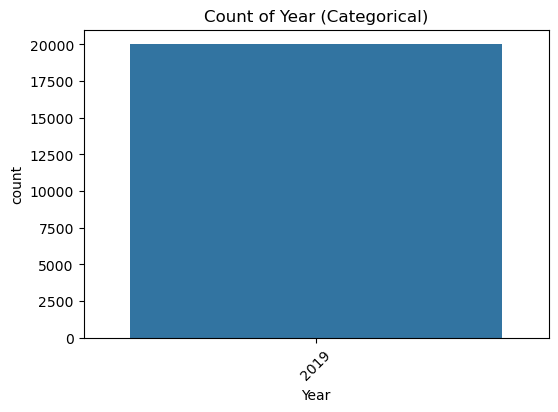

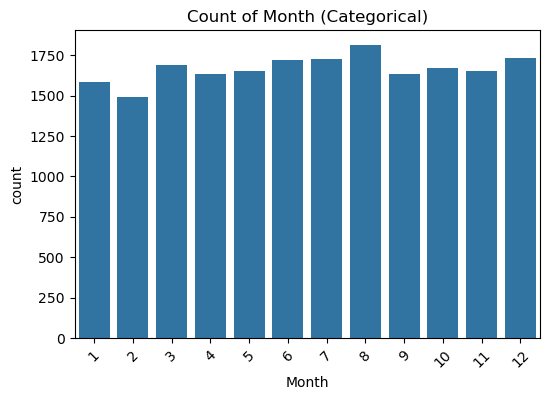

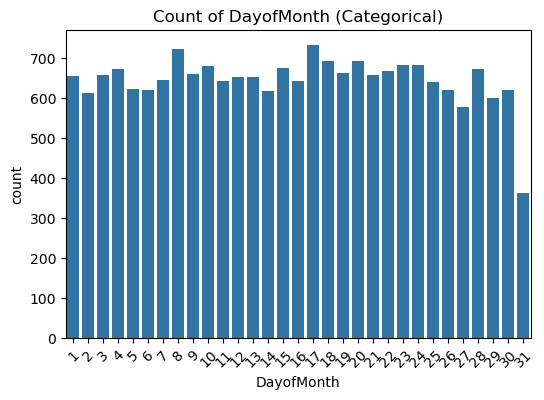

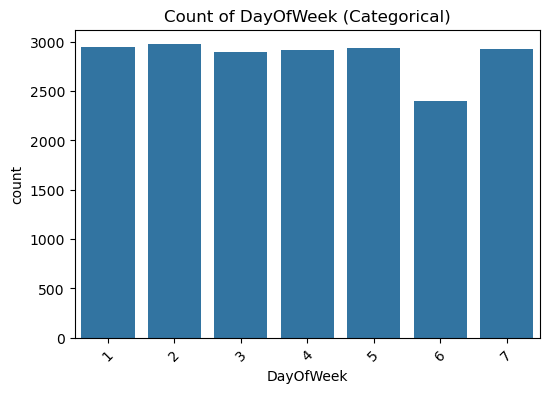

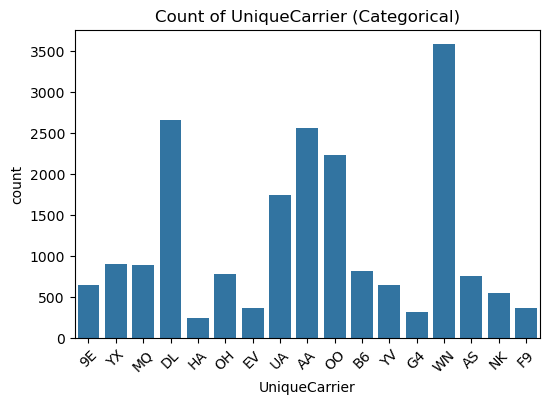

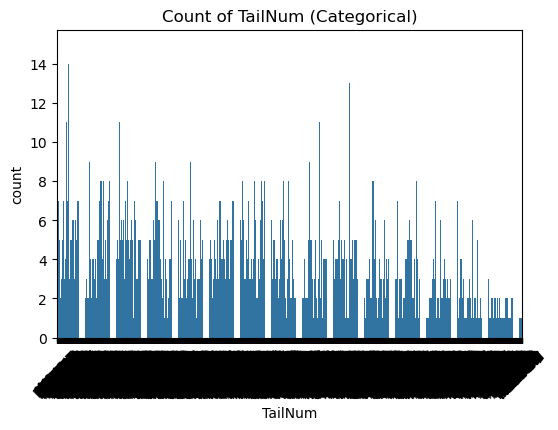

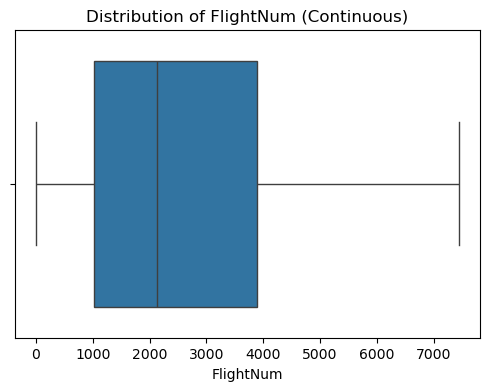

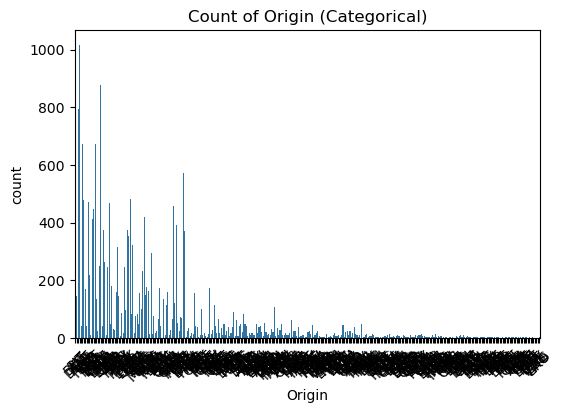

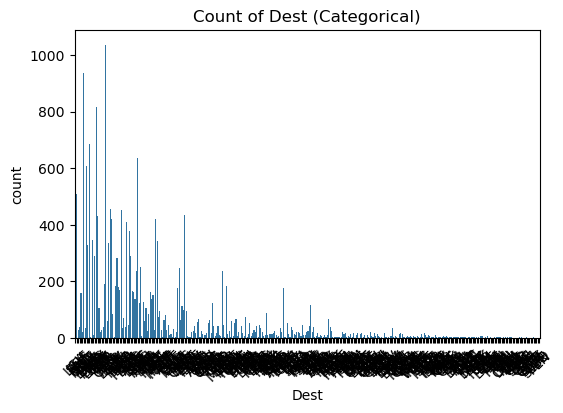

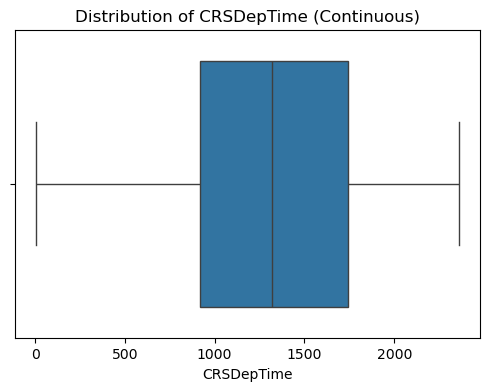

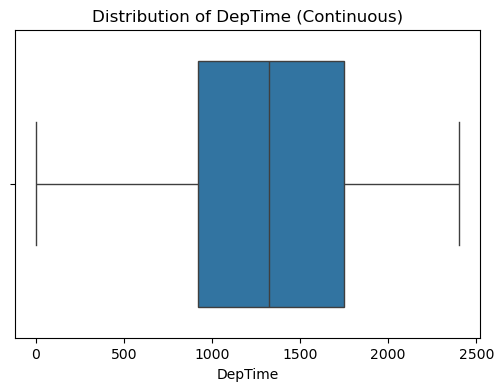

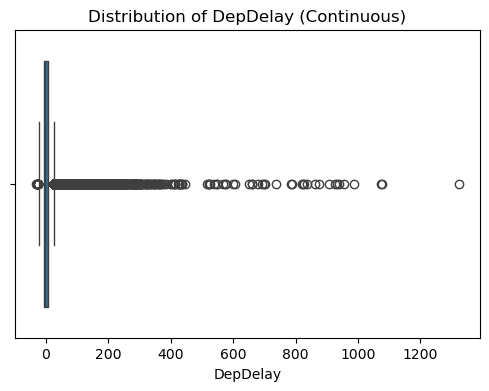

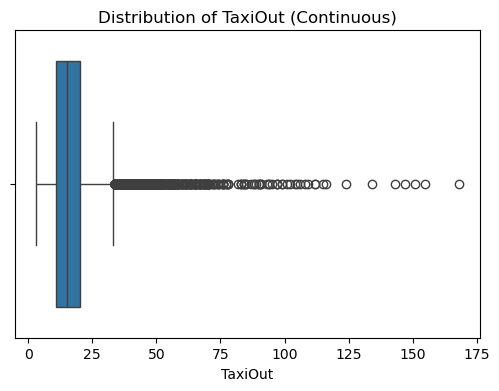

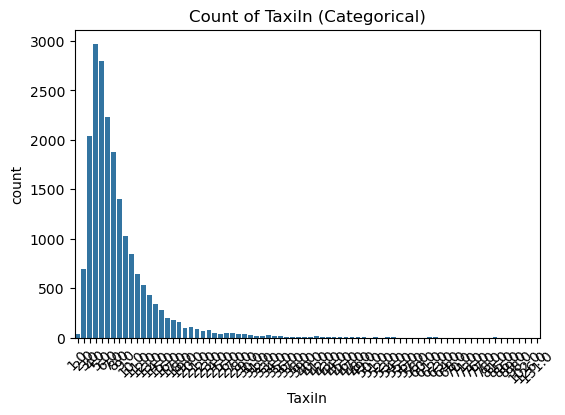

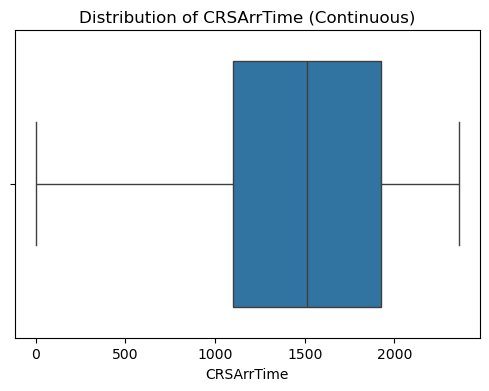

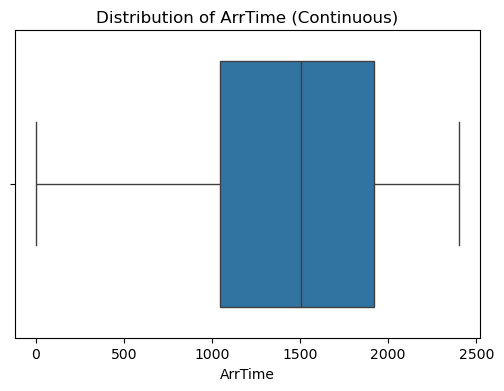

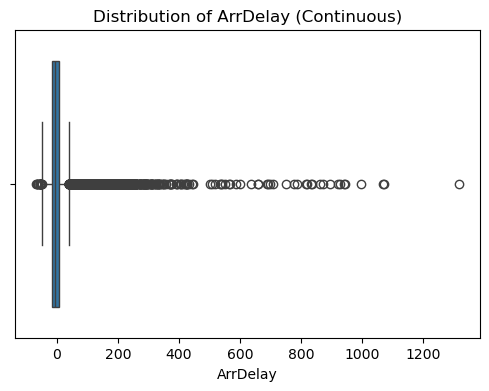

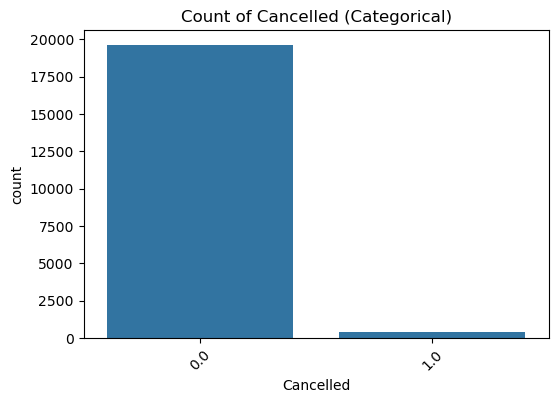

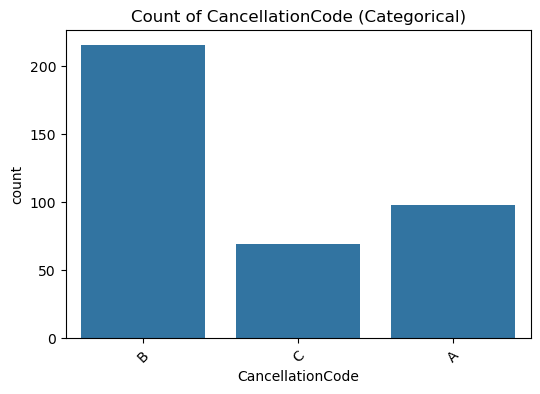

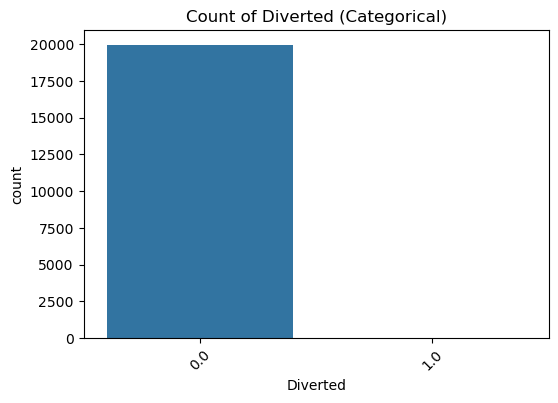

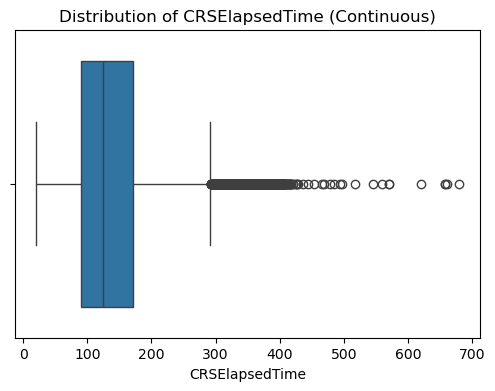

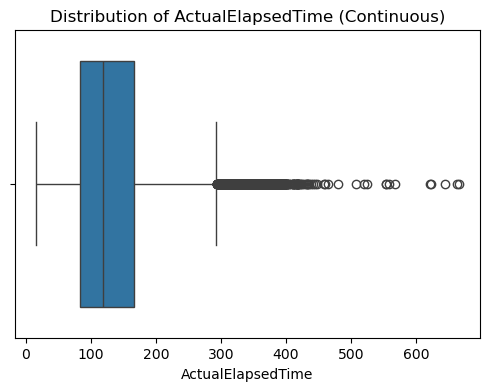

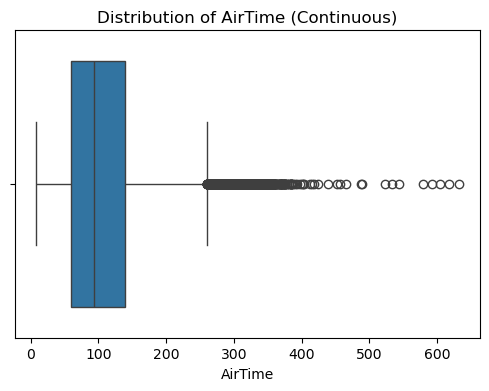

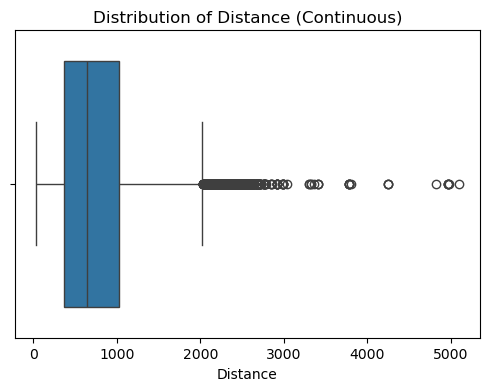

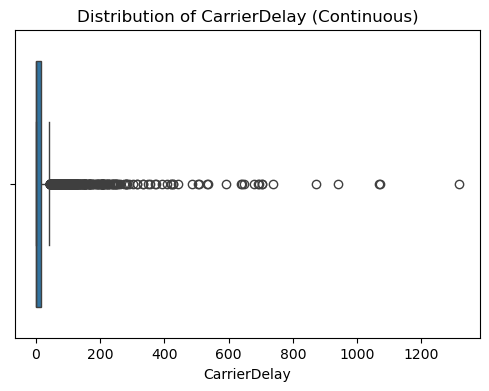

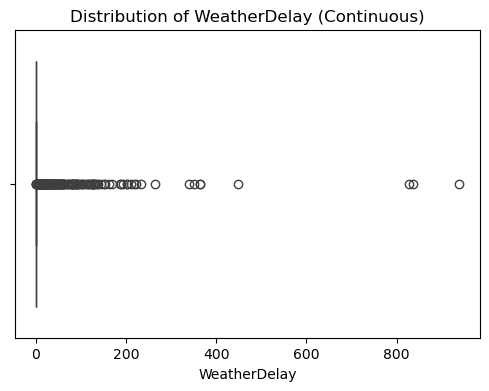

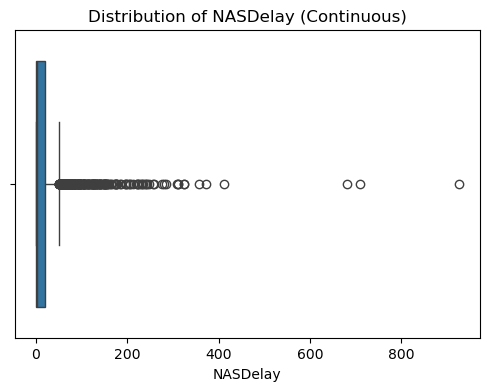

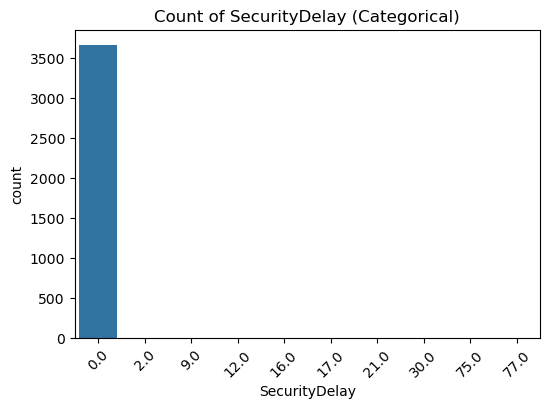

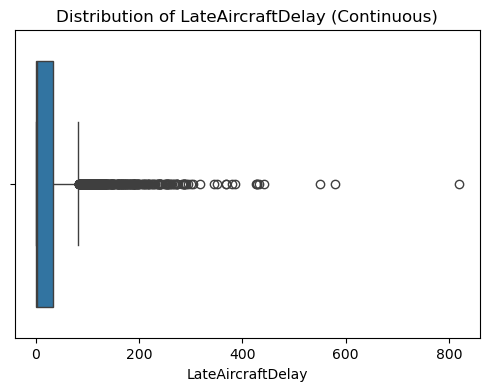

In [46]:
## 3.1 Visualize the value distribution of each column
## If the value type is continuous, we will use boxplot
## If the value type is discrete, we will use bar chart

import matplotlib.pyplot as plt
import seaborn as sns

info = get_info(df_20k)

for col in df_20k.columns:
    plt.figure(figsize=(6, 4))
    
    if col in info.index and info.loc[col, 'var_type'] == 'Continuous':
        sns.boxplot(data=df_20k, x=col)
        plt.title(f'Distribution of {col} (Continuous)')
    else:
        sns.countplot(data=df_20k, x=col)
        plt.title(f'Count of {col} (Categorical)')
        plt.xticks(rotation=45)
        
    plt.show()


In [47]:
## 3.2 Calculate the missing value percentage of each column
missing_percentages = df_20k.isnull().mean() * 100

print("Missing Value Percentages (%):")
print(missing_percentages.sort_values(ascending=False))


Missing Value Percentages (%):
CancellationCode     98.085
LateAircraftDelay    81.620
SecurityDelay        81.620
NASDelay             81.620
WeatherDelay         81.620
CarrierDelay         81.620
AirTime               2.135
ArrDelay              2.135
ActualElapsedTime     2.135
TaxiIn                1.950
ArrTime               1.950
TaxiOut               1.910
DepTime               1.855
DepDelay              1.855
TailNum               0.290
Distance              0.000
CRSElapsedTime        0.000
Diverted              0.000
Year                  0.000
Cancelled             0.000
Month                 0.000
CRSDepTime            0.000
Dest                  0.000
Origin                0.000
FlightNum             0.000
UniqueCarrier         0.000
DayOfWeek             0.000
DayofMonth            0.000
CRSArrTime            0.000
dtype: float64


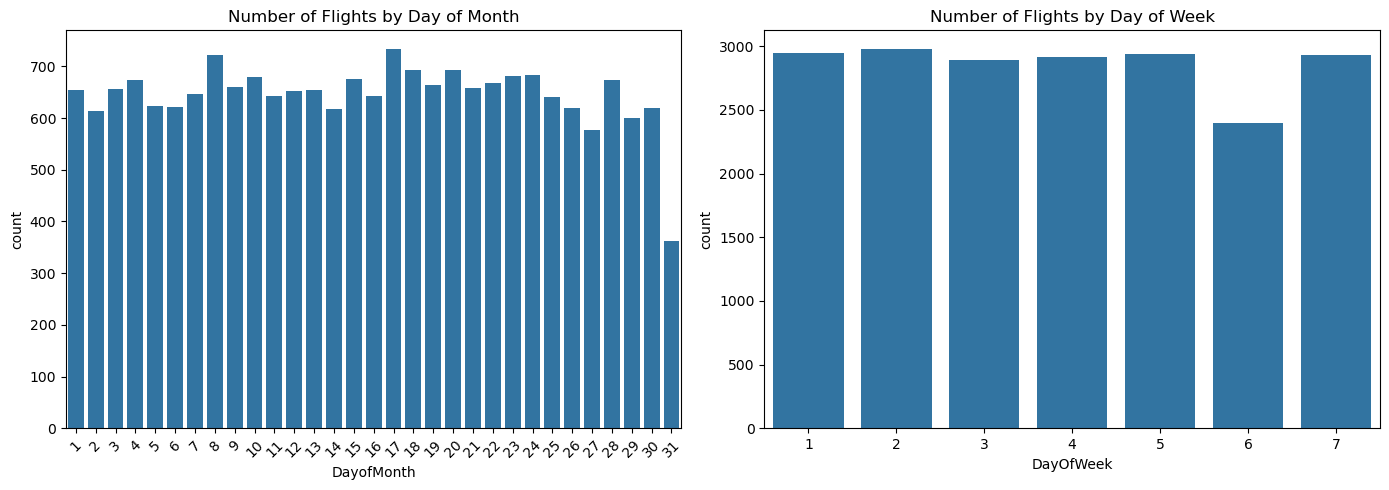

In [ ]:
## 3.3 Count number of flights in different DayofMonth and DayOfWeek
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
## Visualize with Barchart

sns.countplot(data=df_20k, x='DayofMonth', ax=axes[0])
axes[0].set_title('Number of Flights by Day of Month')
axes[0].tick_params(axis='x', rotation=45)
sns.countplot(data=df_20k, x='DayOfWeek', ax=axes[1])
axes[1].set_title('Number of Flights by Day of Week')

plt.tight_layout()
plt.show()

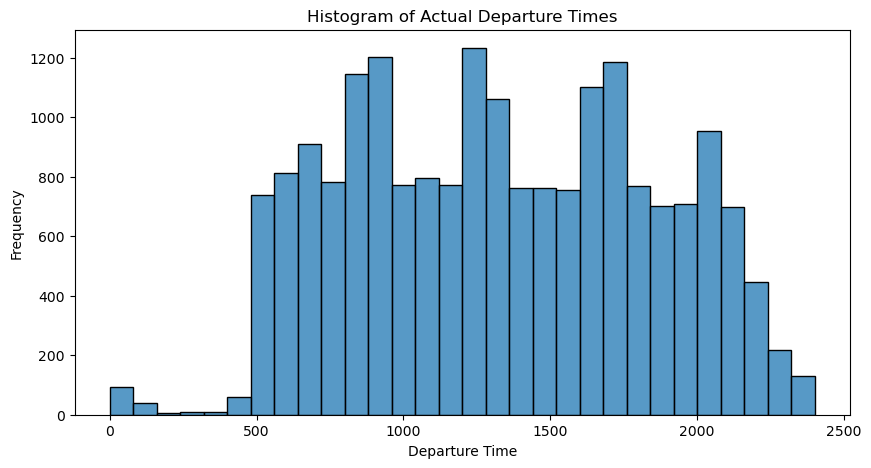

In [64]:
## 3.4.1 Histogram of Departure Time
plt.figure(figsize=(10, 5))
sns.histplot(df_20k['DepTime'].dropna(), bins=30)
plt.title('Histogram of Actual Departure Times')
plt.xlabel('Departure Time')
plt.ylabel('Frequency')
plt.show()

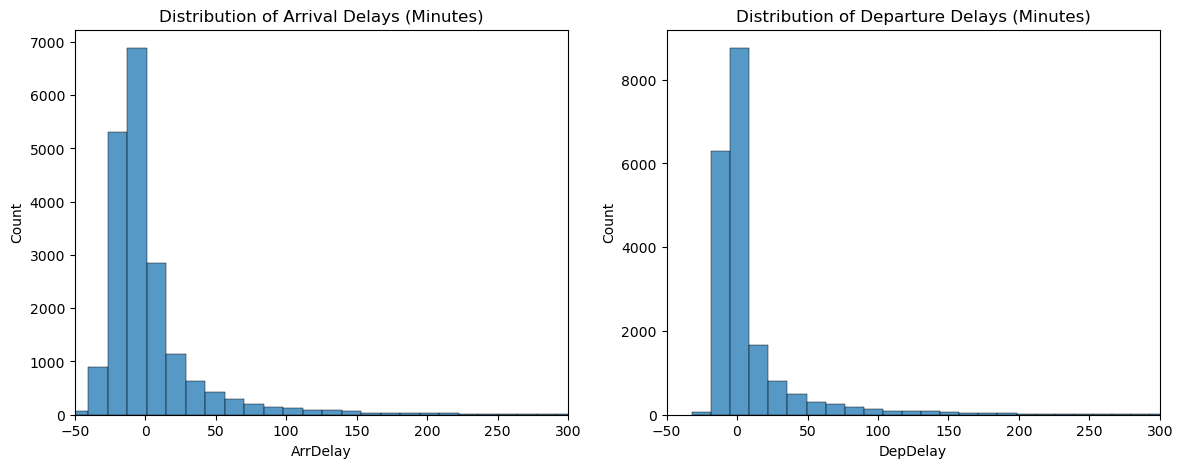

In [59]:
## 3.4.2 Histogram of arrival and departure delays
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Arrivals
sns.histplot(df_20k['ArrDelay'].dropna(), bins=100, ax=axes[0])
axes[0].set_title('Distribution of Arrival Delays (Minutes)')
axes[0].set_xlim(-50, 300) 

# Departures
sns.histplot(df_20k['DepDelay'].dropna(), bins=100, ax=axes[1])
axes[1].set_title('Distribution of Departure Delays (Minutes)')
axes[1].set_xlim(-50, 300)

plt.show()

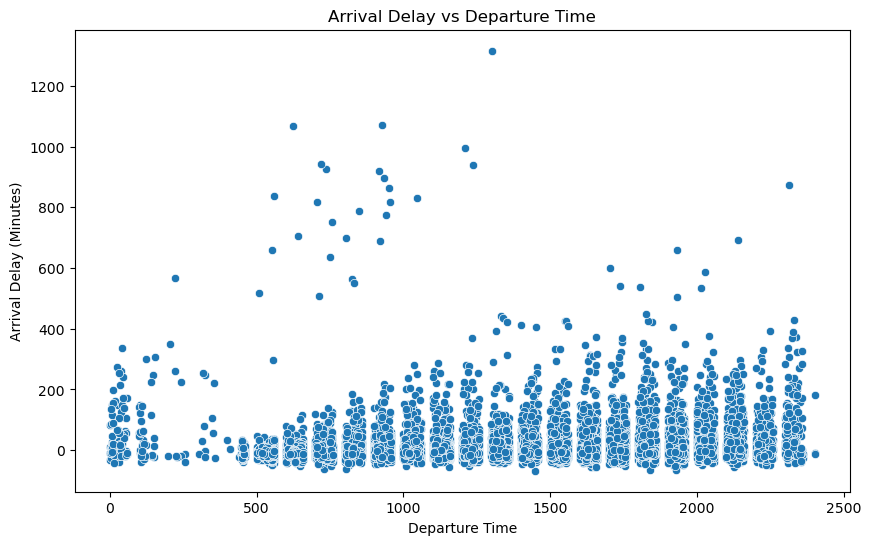

In [63]:
## 3.5.1 bivariate analysis: arrival delay vs departure time
# plot of arrival delay vs departure time Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_20k, x='DepTime', y='ArrDelay')
plt.title('Arrival Delay vs Departure Time')
plt.xlabel('Departure Time')
plt.ylabel('Arrival Delay (Minutes)')
plt.show()

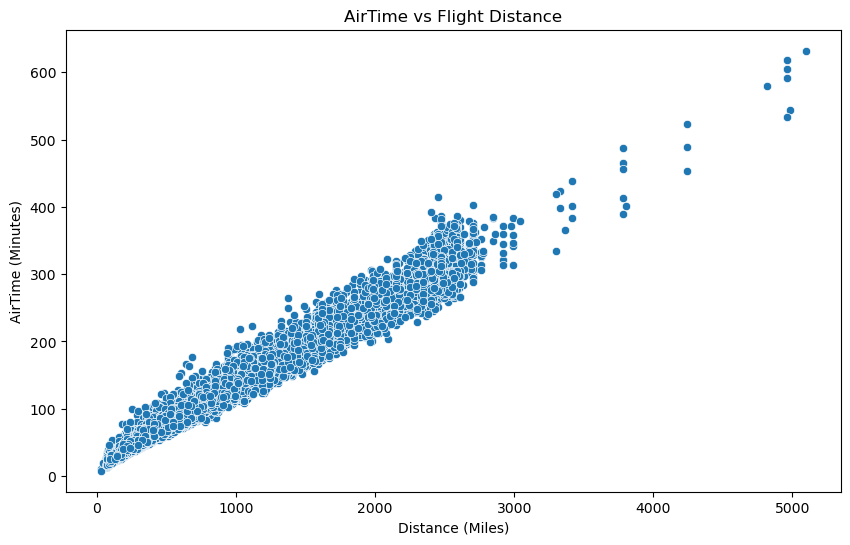

In [65]:
## 3.5.2 bivariate analysis: distance and airtimes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_20k, x='Distance', y='AirTime')
plt.title('AirTime vs Flight Distance')
plt.xlabel('Distance (Miles)')
plt.ylabel('AirTime (Minutes)')
plt.show()

### 4. Feature engineering and cleaning

In [66]:
## 4.1 creating a categorical column for weekday
## {      1: 'Monday',
##        2: 'Tuesday',
##        3: 'Wednesday',
##        4: 'Thursday',
##        5: 'Friday',
##        6: 'Saturday',
##        7: 'Sunday'}

weekday_map = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

df_20k['Weekday_Name'] = df_20k['DayOfWeek'].map(weekday_map)

df_20k[['DayOfWeek', 'Weekday_Name']].head()

,DayOfWeek,Weekday_Name
40894,5,Friday
72876,7,Sunday
34581,4,Thursday
63493,5,Friday
15251,3,Wednesday


In [ ]:
## 4.2 first use a max(0,x) transform to get rid of negative values
## then create a new column using the log(1+x)
import numpy as np

df_20k['ArrDelay_Log'] = np.log1p(df_20k['ArrDelay'].clip(lower=0)) # previously, would've had NaNs without clip
df_20k['DepDelay_Log'] = np.log1p(df_20k['DepDelay'].clip(lower=0))

print(df_20k['ArrDelay_Log'].head())
df_20k['DepDelay_Log'].head()

40894    0.693147
72876    0.000000
34581    0.000000
63493    3.988984
15251    1.098612
Name: ArrDelay_Log, dtype: float64


40894    3.583519
72876    0.000000
34581    0.000000
63493    3.970292
15251    1.386294
Name: DepDelay_Log, dtype: float64

In [73]:
## 4.3 Create a new column called 'DecimalDepTime', which convert 'CRSDepTime' (HHMM format) into decimal house
## For example: 1330 --> 13.5; 9:45 --> 9.75
h = df_20k['CRSDepTime'] // 100
m = df_20k['CRSDepTime'] % 100

df_20k['DecimalDepTime'] = h + (m / 60.0)

df_20k[['CRSDepTime', 'DecimalDepTime']].head()

,CRSDepTime,DecimalDepTime
40894,540,5.666667
72876,1132,11.533333
34581,1440,14.666667
63493,1102,11.033333
15251,1351,13.850000


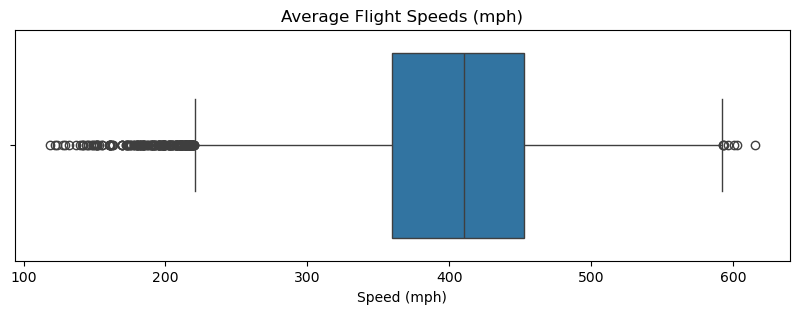

In [76]:
## 4.4 Create a new column 'speed', which is equal distance/AirTime. Make sure the unit of column is Miles Per Hour (mph)
df_20k['Speed_mph'] = df_20k['Distance'] / (df_20k['AirTime'] / 60.0)
df_20k['Speed_mph'] = df_20k['Speed_mph'].replace([np.inf, -np.inf], np.nan)

## boxplots of average speeds
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_20k['Speed_mph'].dropna())
plt.title('Average Flight Speeds (mph)')
plt.xlabel('Speed (mph)')
plt.show()

In [82]:

df_20k[['Distance', 'AirTime', 'Speed_mph']]

,Distance,AirTime,Speed_mph
40894,292.0,55.0,318.545455
72876,1117.0,147.0,455.918367
34581,364.0,54.0,404.444444
63493,271.0,48.0,338.750000
15251,163.0,30.0,326.000000
...,...,...,...
48988,611.0,NaN,NaN
68428,239.0,42.0,341.428571
49471,814.0,119.0,410.420168
10426,2688.0,315.0,512.000000


In [85]:
#### 4.5 Filter flights with speeds greater than 650 mph and calculate their proportion in the dataset.
fast_flights = df_20k[df_20k['Speed_mph'] > 650]
total_flights = df_20k['Speed_mph'].notna().sum()

print(f'{len(fast_flights) / total_flights}%')


0.0%


### 5. Save transformed data
This corresponds to the "Load" part in ETL

Regarding the saved file format
- raw CSV is good for sharing
- Parquet is better for analytics workflows

You can choose whatever format you like to save the transformed data in this exercise.

In [86]:
## Save transformed data
output_file = DATA_DIR + 'airline_2019_transformed.csv'
df_20k.to_csv(output_file, index=False)
print("saved")

saved
